# Chapter 2 - Dispersion Suppressor

This notebook develops the dispersion suppressor in a SciBmad / Julia workflow.

## Introduction

To connect an arc to the following straight section in a sextant, the dispersion in the straight section must be suppressed to zero while minimally changing the betas. For a $90^\circ$ lattice, this can be approximately achieved by using two equivalent arc FODO cells with the bends at half-strength. For FODO cells with different phase advance, dispersion suppressors can also be constructed from the last two cells by changing their bend strengths. For 60-degree FODOs, for example, the first FODO has zero bend strength, and the last has the full bend strength. To get the dispersion and dispersion derivative at the end of the dispersion suppressor exactly zero, the last two quadrupoles can be minimally varied.

![Dispersion suppressor.](assets/chapter2_dispersion_suppressor.png)

*Figure 1: Dispersion suppressor.*


## Goal

At the end of the arc, we want to connect into a straight section with **zero horizontal dispersion**.  
For a 90-degree FODO lattice, a natural first guess is to replace the bends in the last two cells by **half-strength bends**.  
That gives an approximate suppressor. Then we **optimize the strengths of the last two quadrupoles** so that

$$
\eta_x(\mathrm{end}) = 0,
\qquad
\eta_x'(\mathrm{end}) = 0.
$$

These two special quadrupoles are called **QFF1** and **QDF1**.

## Workflow in this notebook

1. Rebuild the optimized forward arc FODO cell from Chapter 1.
2. Extract the periodic one-cell optics and dispersion from its linear map.
3. Build the forward dispersion suppressor with half-strength bends.
4. Define a merit function from the end-of-line values of $\eta_x$ and $\eta_x'$.
5. Optimize the strengths of `QFF1` and `QDF1`.
6. Verify that the suppressor ends with zero dispersion.


In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [3]:
using SciBmad
using LinearAlgebra
using Printf
using CairoMakie
using DifferentiationInterface
import DifferentiationInterface as DI
using GTPSA

species_ref = Species("electron")
E_ref = 18e9

1.8e10

## 2.1. Low-level helper functions

We will keep the optics extraction very explicit.

The idea is:

- use `track!` to propagate one particle through a `Beamline`,
- use `DifferentiationInterface` with `AutoGTPSA()` to compute the **Jacobian** of the end coordinates with respect to the initial coordinates,
- interpret that Jacobian as the **linear transfer map**.

For the optimization steps below, we also use a descriptor of the form `Descriptor(6, 2, nknob, 1)`. The six ordinary GTPSA variables represent the initial phase-space coordinates, while the `nknob` parameters represent small changes in the quadrupole strengths being optimized. Extracting the first-order map coefficient with `par(..., [powers...,:])` preserves its dependence on those strength parameters, so the residual Jacobian can be read directly from `GTPSA.gradient(..., include_params=true)`.

For an open line, the horizontal dispersion at the end is obtained from the map by

$$
D_{\mathrm{end}} = A D_0 + b,
$$

where $A$ is the $2\times 2$ transverse block of the map, $D_0 = (\eta_x,\eta_x')^T$ is the entrance dispersion vector, and $b$ is the column multiplying the momentum offset coordinate.

For the periodic arc cell, the periodic dispersion satisfies

$$
D_0 = A D_0 + b
\quad\Longrightarrow\quad
(I-A)D_0 = b.
$$


In [4]:
function track_a_particle(v0, beamline)
    x = similar(v0)
    x .= v0
    bunch = Bunch(x; species=beamline.species_ref, p_over_q_ref=beamline.p_over_q_ref)
    track!(bunch, beamline)
    return copy(bunch.coords.v)
end

function linear_map(beamline; x0=zeros(6))
    prep = DI.prepare_jacobian(track_a_particle, AutoGTPSA(), x0, DI.Constant(beamline))
    return DI.jacobian(track_a_particle, prep, AutoGTPSA(), x0, DI.Constant(beamline))
end

function linear_map_with_descriptor(beamline, d; x0=zeros(6))
    xvars = vars(d)
    v0 = [x0[i] + xvars[i] for i in 1:6]
    vout = track_a_particle(v0, beamline)

    M = Matrix{Any}(undef, 6, 6)
    for i in 1:6, j in 1:6
        powers = zeros(Int, 6)
        powers[j] = 1
        M[i, j] = par(vout[i], [powers...,:])
    end
    return M
end

parameter_gradient(x) = GTPSA.gradient(x, include_params=true)[7:end]
tps_const(x) = try x[zeros(Int, 6)] catch; x end

function stable_phase_advance(M2)
    c_mu = clamp(0.5 * tr(M2), -1.0, 1.0)
    return acos(c_mu)
end

function stable_phase_advance_with_params(M2)
    c_mu = 0.5 * tr(M2)
    return acos(c_mu)
end

function periodic_twiss_from_map(M2)
    mu = stable_phase_advance(M2)
    s_mu = sin(mu)
    beta = M2[1, 2] / s_mu
    alpha = (M2[1, 1] - M2[2, 2]) / (2s_mu)
    return (beta=beta, alpha=alpha, mu=mu)
end

function propagate_twiss(A, tw0)
    beta0 = tw0.beta
    alpha0 = tw0.alpha
    gamma0 = (1 + alpha0^2) / beta0

    beta = A[1,1]^2 * beta0 - 2A[1,1]*A[1,2]*alpha0 + A[1,2]^2 * gamma0
    alpha = -A[1,1]*A[2,1]*beta0 + (A[1,1]*A[2,2] + A[1,2]*A[2,1])*alpha0 - A[1,2]*A[2,2]*gamma0

    return (beta=beta, alpha=alpha)
end

function periodic_dispersion_from_map(M)
    A = M[1:2, 1:2]
    b = M[1:2, 6]
    D = (I - A) \ b
    return (eta=D[1], etap=D[2])
end

function transport_dispersion(M, D0)
    D = M[1:2, 1:2] * [D0.eta, D0.etap] + M[1:2, 6]
    return (eta=D[1], etap=D[2])
end


transport_dispersion (generic function with 1 method)

## 2.2. Rebuild the forward arc FODO cell from Chapter 1

This chapter starts from the **optimized forward arc cell**.  
Chapter 1 already solved for the quadrupole strengths that give a **90-degree phase advance in both transverse planes**, and saved those values in a small Julia solution file. Here we load that result directly, then rebuild the same forward arc FODO geometry.

We use the following geometry:

- $QF$: focusing quadrupole, $L=0.5$
- $QD$: defocusing quadrupole, $L=0.5$
- $D1$: drift, $L=0.609$
- $D2$: drift, $L=1.241$
- $B$: bend, $L=6.86$, $\theta=\pi/132$

The forward arc cell is

$$
(QF,\ D1,\ B,\ D2,\ QD,\ D1,\ B,\ D2).
$$


In [5]:
function make_forward_arc_fodo(kqf, kqd; knobs=nothing)
    qf = Quadrupole(L=0.5, Kn1=kqf)
    qd = Quadrupole(L=0.5, Kn1=kqd)
    if knobs !== nothing
        qf.Kn1 = qf.Kn1 + knobs[1]
        qd.Kn1 = qd.Kn1 + knobs[2]
    end

    elements = [
        qf,
        Drift(L=0.609),
        SBend(L=6.86, angle=pi/132),
        Drift(L=1.241),
        qd,
        Drift(L=0.609),
        SBend(L=6.86, angle=pi/132),
        Drift(L=1.241),
    ]

    lengths = [0.5, 0.609, 6.86, 1.241, 0.5, 0.609, 6.86, 1.241]
    names = ["QF", "D1", "B1", "D2", "QD", "D1", "B2", "D2"]

    beamline = Beamline(elements; species_ref=Species("electron"), E_ref=18e9)
    return (; elements, lengths, names, beamline)
end

chapter1_forward_solution = joinpath(pwd(), "lattices", "chapter_1", "chapter1_fodoF_solution.jl")
isfile(chapter1_forward_solution) || error("Cannot find chapter1_fodoF_solution.jl. Run Chapter 1 first.")
include(chapter1_forward_solution)

@printf("Loaded Chapter 1 arc strengths:\n")
@printf("  QF.Kn1 = %.12f\n", kQF_arc)
@printf("  QD.Kn1 = %.12f\n", kQD_arc)


Loaded Chapter 1 arc strengths:
  QF.Kn1 = 0.312659097023
  QD.Kn1 = -0.312792879287


In [6]:
arc = make_forward_arc_fodo(kQF_arc, kQD_arc)
M_arc = linear_map(arc.beamline)

twiss_x0 = periodic_twiss_from_map(M_arc[1:2, 1:2])
twiss_y0 = periodic_twiss_from_map(M_arc[3:4, 3:4])
disp0 = periodic_dispersion_from_map(M_arc)

@printf("Periodic one-cell optics of the arc:\n")
@printf("  beta_x(start)  = %.8f m\n", twiss_x0.beta)
@printf("  alpha_x(start) = %.8f\n", twiss_x0.alpha)
@printf("  mu_x           = %.8f rad\n", twiss_x0.mu)
@printf("  beta_y(start)  = %.8f m\n", twiss_y0.beta)
@printf("  alpha_y(start) = %.8f\n", twiss_y0.alpha)
@printf("  mu_y           = %.8f rad\n", twiss_y0.mu)
@printf("  eta_x(start)   = %.8e m\n", disp0.eta)
@printf("  eta_x'(start)  = %.8e\n", disp0.etap)


Periodic one-cell optics of the arc:
  beta_x(start)  = 30.62332067 m
  alpha_x(start) = -2.40141141
  mu_x           = 1.57076056 rad
  beta_y(start)  = 5.54917149 m
  alpha_y(start) = 0.47668277
  mu_y           = 1.57076052 rad
  eta_x(start)   = 5.86743658e-01 m
  eta_x'(start)  = 4.53327007e-02


## 2.3. Build the forward dispersion suppressor

Now we switch from a **periodic cell problem** to an **open transfer line** problem.

The suppressor layout is

$$
(QF,\ D1,\ BH,\ D2,\ QD,\ D1,\ BH,\ D2,\ QFF1,\ D1,\ BH,\ D2,\ QDF1,\ D1,\ BH,\ D2),
$$

where the bend `BH` has **half** the arc bending angle.  
The first two quadrupoles stay fixed at the optimized arc strengths.  
The last two quadrupoles, `QFF1` and `QDF1`, are the variables we will optimize.

We begin with the initial guess

$$
QFF1 = 0.3, \qquad QDF1 = -0.3.
$$


In [7]:
function make_forward_suppressor(kqf_arc, kqd_arc, kqff1, kqdf1; knobs=nothing)
    half_angle = (pi/132) / 2
    qff1 = Quadrupole(L=0.5, Kn1=kqff1)
    qdf1 = Quadrupole(L=0.5, Kn1=kqdf1)
    if knobs !== nothing
        qff1.Kn1 = qff1.Kn1 + knobs[1]
        qdf1.Kn1 = qdf1.Kn1 + knobs[2]
    end

    elements = [
        Quadrupole(L=0.5, Kn1=kqf_arc),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        Quadrupole(L=0.5, Kn1=kqd_arc),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        qff1,
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        qdf1,
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),
    ]

    lengths = [
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
    ]

    names = [
        "QF", "D1", "BH1", "D2",
        "QD", "D1", "BH2", "D2",
        "QFF1", "D1", "BH3", "D2",
        "QDF1", "D1", "BH4", "D2",
    ]

    beamline = Beamline(elements; species_ref=Species("electron"), E_ref=18e9)
    return (; elements, lengths, names, beamline)
end

make_forward_suppressor (generic function with 1 method)

## 2.4. Scan the line before optimization

Before optimizing anything, it is useful to inspect the suppressor as built from the half-strength bends alone.

We propagate:

- the **periodic arc Twiss parameters** from the start of the open line,
- the **periodic arc dispersion vector** from the start of the open line.

That lets us look at the optics element-by-element along the suppressor.


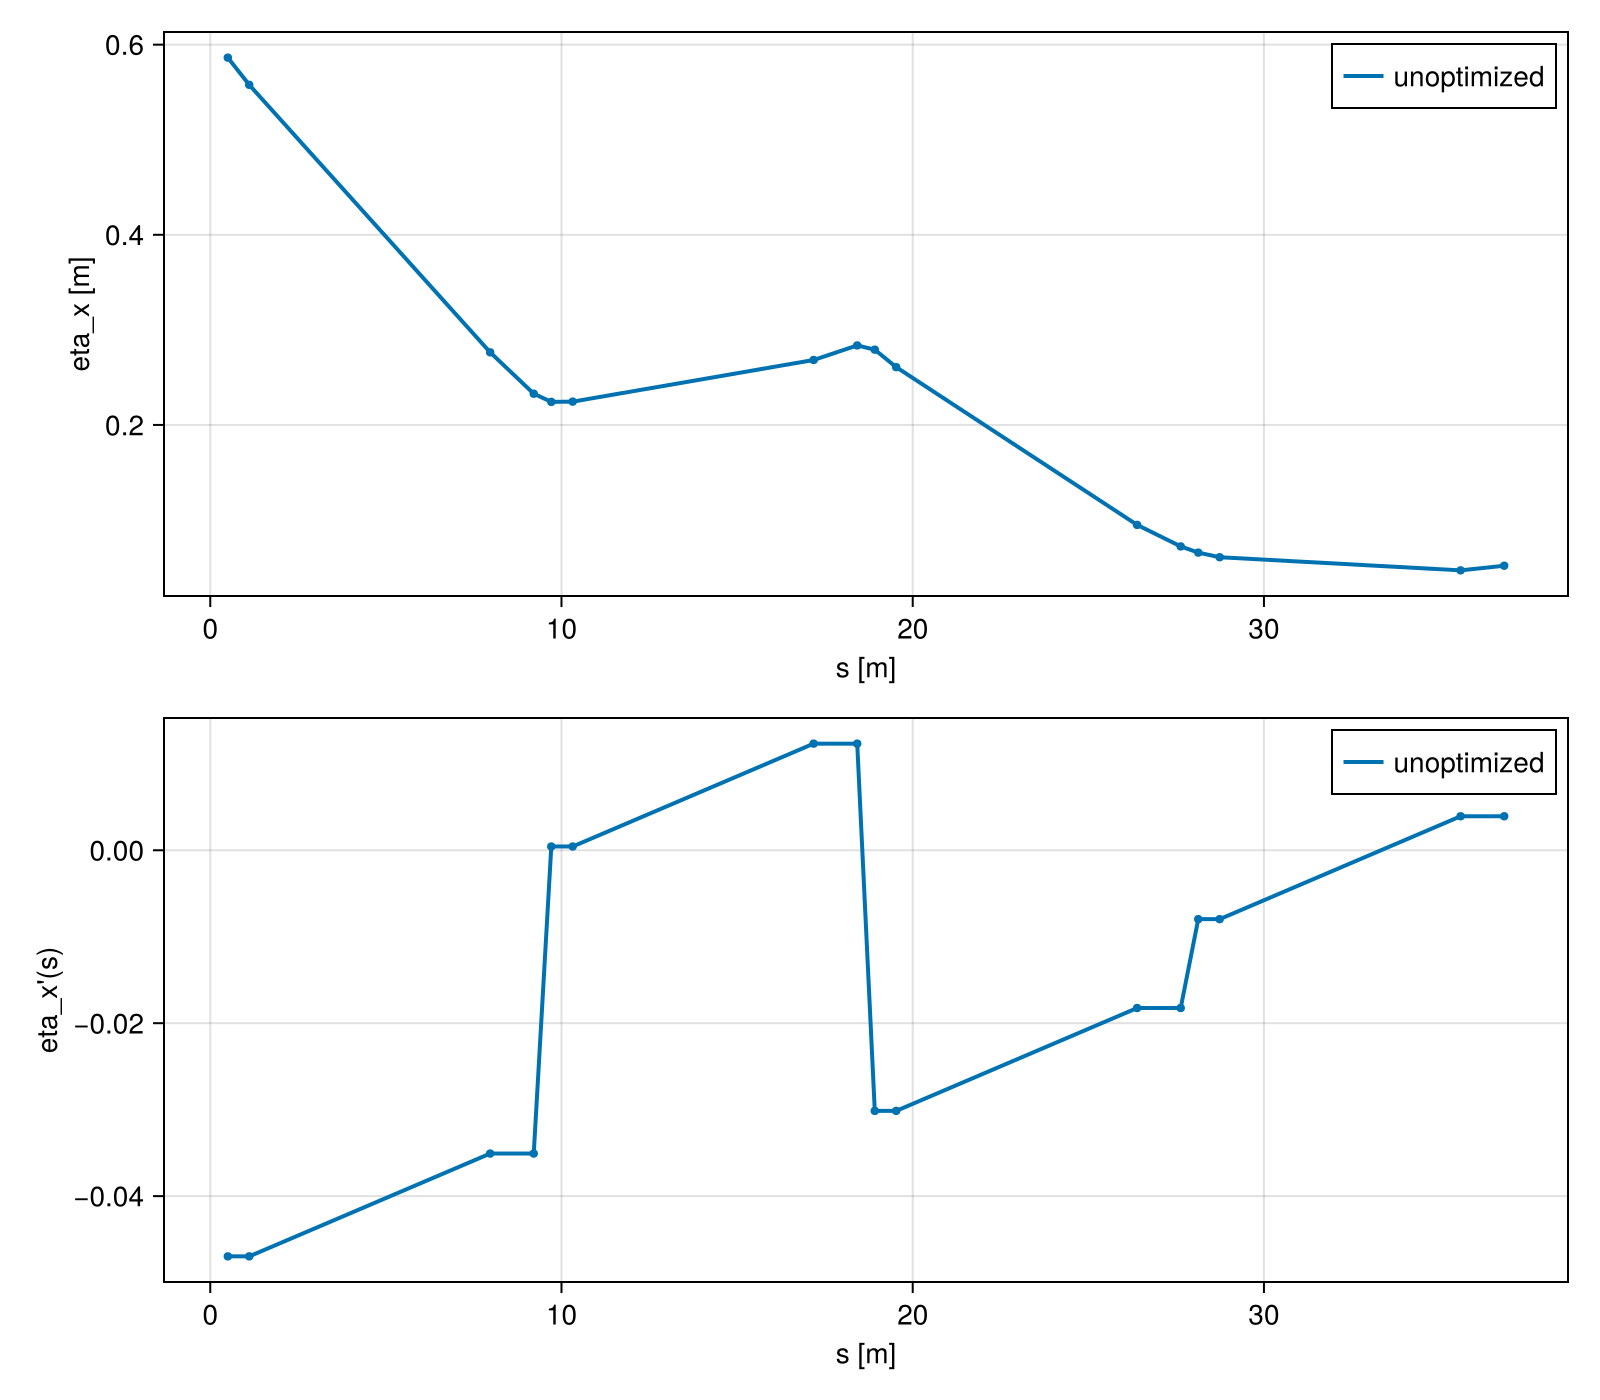

In [7]:
k_special0 = [0.3, -0.3]
d_scan_knobs = Descriptor(6, 2, 2, 1)

function optics_scan(elements, lengths, names, twx0, twy0, D0)
    n = length(elements)
    s = cumsum(lengths)

    etax  = zeros(n)
    etaxp = zeros(n)
    betax  = zeros(n)
    betay  = zeros(n)

    for i in 1:n
        prefix = deepcopy_no_beamline.(elements[1:i])
        bl = Beamline(prefix; species_ref=Species("electron"), E_ref=18e9)
        M = tps_const.(linear_map_with_descriptor(bl, d_scan_knobs))

        D = transport_dispersion(M, D0)
        etax[i]  = D.eta
        etaxp[i] = D.etap

        betax[i] = propagate_twiss(M[1:2, 1:2], twx0).beta
        betay[i] = propagate_twiss(M[3:4, 3:4], twy0).beta
    end

    return (; s, names, etax, etaxp, betax, betay)
end

lat0 = make_forward_suppressor(kQF_arc, kQD_arc, k_special0[1], k_special0[2])
scan0 = Base.invokelatest(optics_scan, lat0.elements, lat0.lengths, lat0.names, twiss_x0, twiss_y0, disp0)

fig = Figure(size = (800, 700))
ax1 = Axis(fig[1, 1]; xlabel = "s [m]", ylabel = "eta_x [m]")
lines!(ax1, scan0.s, scan0.etax; linewidth = 2, label = "unoptimized")
scatter!(ax1, scan0.s, scan0.etax; markersize = 6)
axislegend(ax1)

ax2 = Axis(fig[2, 1]; xlabel = "s [m]", ylabel = "eta_x'(s)")
lines!(ax2, scan0.s, scan0.etaxp; linewidth = 2, label = "unoptimized")
scatter!(ax2, scan0.s, scan0.etaxp; markersize = 6)
axislegend(ax2)

fig

## 2.5. Optimization

Now we make the optimization problem explicit.

We want the suppressor to end with zero dispersion and zero dispersion derivative, so we define

$$
M(k_{QFF1}, k_{QDF1})
=
w_\eta\,\eta_x(\mathrm{end})^2
+
w_{\eta'}\,\eta_x'(\mathrm{end})^2.
$$

In this notebook we take both weights equal to 1.  

To compute the derivatives used by the optimizer, we add a GTPSA descriptor to the suppressor-building step. The two descriptor parameters represent the strength changes of QFF1 and QDF1. With this construction, the end dispersion values $\eta_x$ and $\eta_x'$ are GTPSA objects. The residuals are computed from their constant terms, while the Jacobian is read from their parameter gradients.



In [9]:
d_suppressor_knobs = Descriptor(6, 2, 2, 1)
dk_suppressor = params(d_suppressor_knobs)

function suppressor_end_dispersion_with_knobs(k_special)
    lat = Base.invokelatest(make_forward_suppressor, kQF_arc, kQD_arc, k_special[1], k_special[2]; knobs=dk_suppressor)
    M = linear_map_with_descriptor(lat.beamline, d_suppressor_knobs)
    Dend = transport_dispersion(M, disp0)
    return Dend
end

# Here we compute the residuals of dispersion
function suppressor_residuals(k_special)
    Dend = suppressor_end_dispersion_with_knobs(k_special)
    return [tps_const(Dend.eta), tps_const(Dend.etap)]
end

#From the residual we compute the merit
function suppressor_merit(k_special; w_eta=1.0, w_etap=1.0)
    r = Base.invokelatest(suppressor_residuals, k_special)
    return w_eta * r[1]^2 + w_etap * r[2]^2
end

#The Jacobian Matrix
function suppressor_residual_jacobian(k_special)
    Dend = suppressor_end_dispersion_with_knobs(k_special)

    return vcat(parameter_gradient(Dend.eta)', parameter_gradient(Dend.etap)')
end

k_special0 = [0.3, -0.3]
r0 = Base.invokelatest() do
    suppressor_residuals(k_special0)
end

@printf("Unoptimized suppressor end conditions:\n")
@printf("  eta_x(end)  = %.8e m\n", r0[1])
@printf("  eta_x'(end) = %.8e\n", r0[2])
@printf("  merit       = %.8e\n", Base.invokelatest(suppressor_merit, k_special0))

Unoptimized suppressor end conditions:
  eta_x(end)  = 5.19022592e-02 m
  eta_x'(end) = 3.93488680e-03
  merit       = 2.70932785e-03


Because the problem is small, a simple Gauss-Newton iteration is enough. Here we use the residual Jacobian computed above with GTPSA by treating `QFF1` and `QDF1` as descriptor parameters. The `gauss_newton` helper also keeps a centered finite-difference fallback: if no Jacobian is supplied, it estimates the residual derivatives by perturbing each optimization variable.


In [10]:
function gauss_newton(f, x0; jacobian=nothing, step=1e-6, tol=1e-13, maxiter=20, damping=1.0, verbose=true)
    x = copy(x0)
    history = NamedTuple[]

    for it in 1:maxiter
        r = f(x)
        merit = 0.5 * dot(r, r)
        push!(history, (iter=it, x=copy(x), residual=copy(r), merit=merit))

        if verbose
            @printf(
                "iter %2d  merit = %.6e   x = [% .8f, % .8f]   residual = [% .3e, % .3e]\n",
                it, merit, x[1], x[2], r[1], r[2]
            )
        end

        if norm(r) < tol
            return x, history
        end

        J = if jacobian === nothing
            Jfd = zeros(length(r), length(x))
            for j in eachindex(x)
                xp = copy(x); xp[j] += step
                xm = copy(x); xm[j] -= step
                Jfd[:, j] = (f(xp) - f(xm)) / (2 * step)
            end
            Jfd
        else
            jacobian(x)
        end

        delta_x = (J' * J) \ (J' * r)
        x -= damping * delta_x

        if norm(delta_x) < tol
            return x, history
        end
    end

    return x, history
end


gauss_newton (generic function with 1 method)

In [11]:
k_special, suppressor_history = gauss_newton(suppressor_residuals, k_special0; jacobian=suppressor_residual_jacobian, tol=1e-14, maxiter=20)

kQFF1, kQDF1 = k_special
r_opt = suppressor_residuals(k_special)

@printf("Optimized suppressor strengths:\n")
@printf("  QFF1.Kn1 = %.12f\n", kQFF1)
@printf("  QDF1.Kn1 = %.12f\n", kQDF1)
@printf("\n")
@printf("Optimized end conditions:\n")
@printf("  eta_x(end)  = %.12e m\n", r_opt[1])
@printf("  eta_x'(end) = %.12e\n", r_opt[2])
@printf("  merit       = %.12e\n", suppressor_merit(k_special))


iter  1  merit = 1.354664e-03   x = [ 0.30000000, -0.30000000]   residual = [ 5.190e-02,  3.935e-03]
iter  2  merit = 3.667442e-07   x = [ 0.31293050, -0.31155247]   residual = [-8.510e-04, -9.603e-05]
iter  3  merit = 4.412579e-16   x = [ 0.31293818, -0.31531889]   residual = [-2.955e-08, -3.087e-09]
iter  4  merit = 2.222523e-31   x = [ 0.31293818, -0.31531898]   residual = [-6.661e-16,  2.776e-17]
Optimized suppressor strengths:
  QFF1.Kn1 = 0.312938181899
  QDF1.Kn1 = -0.315318984845

Optimized end conditions:
  eta_x(end)  = -6.661338147751e-16 m
  eta_x'(end) = 2.775557561563e-17
  merit       = 4.445046311646e-31


## 2.6. Compare the unoptimized and optimized suppressor

The key check is very simple:

- before optimization, the half-bend construction gets us **close** to zero dispersion,
- after optimization, the last two quadrupole strengths make both $\eta_x$ and $\eta_x'$ vanish at the end of the line.

We also compare the beta functions to confirm that the optics were not dramatically distorted while suppressing the dispersion.


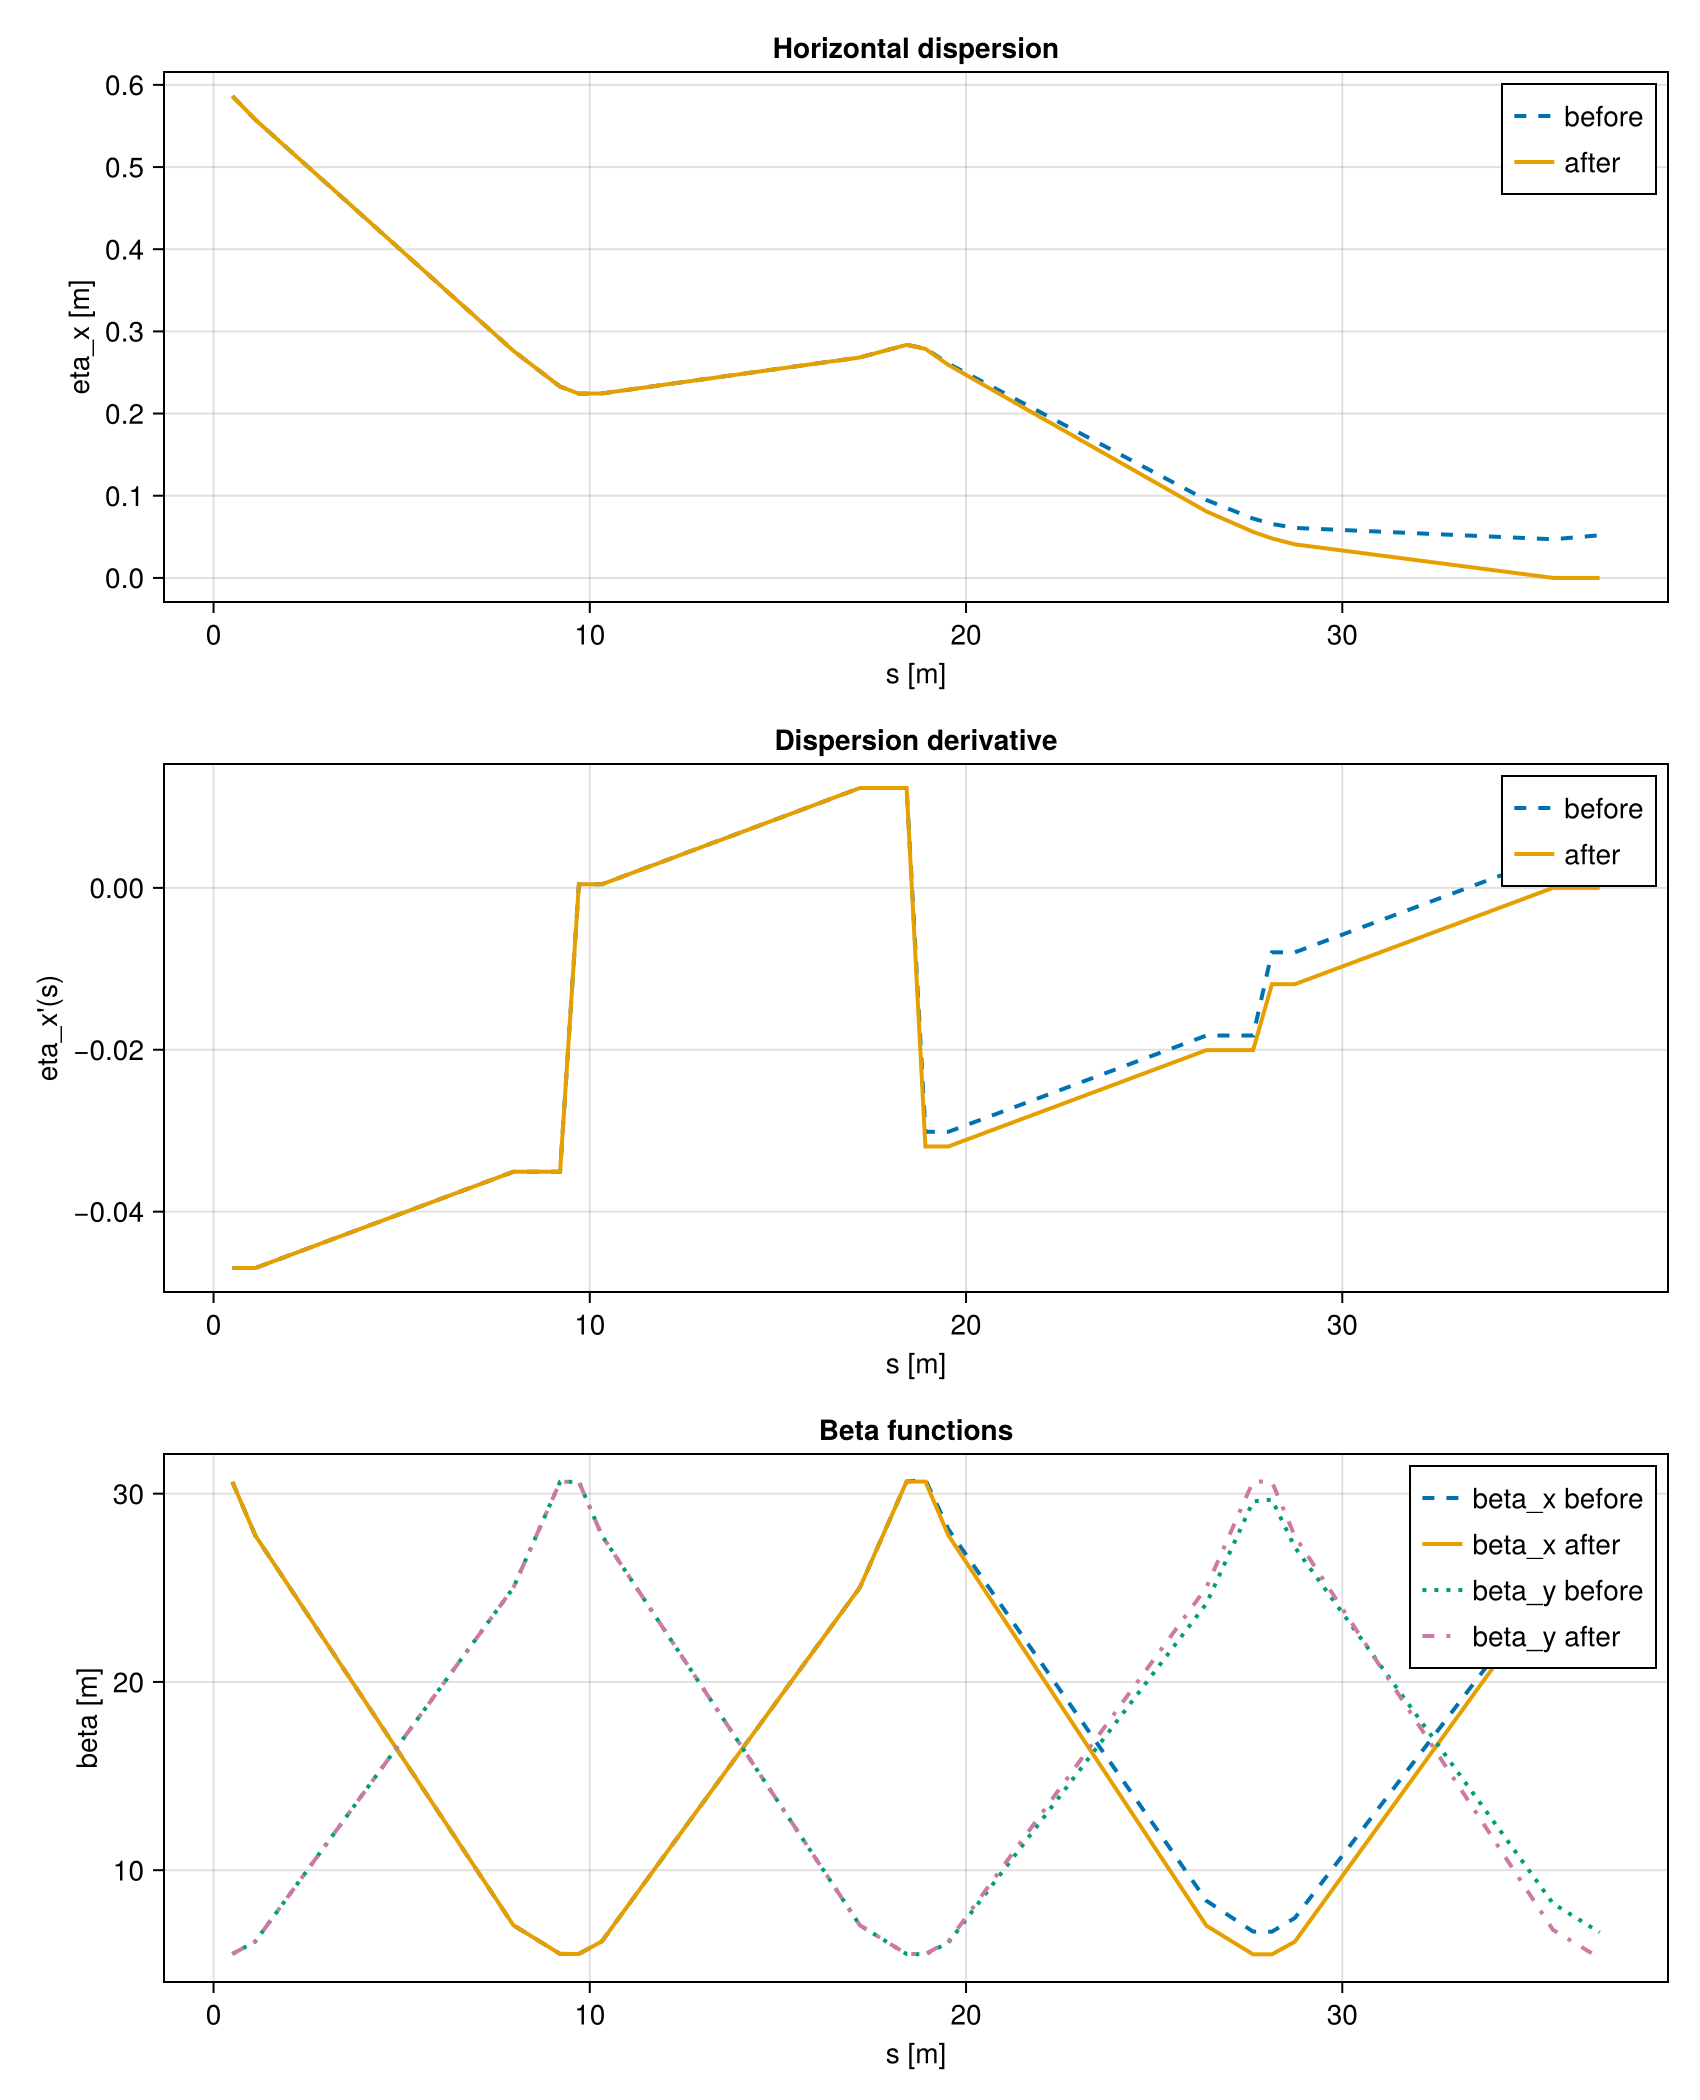

In [11]:
lat_opt = make_forward_suppressor(kQF_arc, kQD_arc, kQFF1, kQDF1)
scan_opt = optics_scan(lat_opt.elements, lat_opt.lengths, lat_opt.names, twiss_x0, twiss_y0, disp0)

fig = Figure(size = (850, 1050))

ax_eta = Axis(fig[1, 1]; xlabel = "s [m]", ylabel = "eta_x [m]", title = "Horizontal dispersion")
lines!(ax_eta, scan0.s, scan0.etax; linewidth = 2, linestyle = :dash, label = "before")
lines!(ax_eta, scan_opt.s, scan_opt.etax; linewidth = 2, label = "after")
axislegend(ax_eta)

ax_etap = Axis(fig[2, 1]; xlabel = "s [m]", ylabel = "eta_x'(s)", title = "Dispersion derivative")
lines!(ax_etap, scan0.s, scan0.etaxp; linewidth = 2, linestyle = :dash, label = "before")
lines!(ax_etap, scan_opt.s, scan_opt.etaxp; linewidth = 2, label = "after")
axislegend(ax_etap)

ax_beta = Axis(fig[3, 1]; xlabel = "s [m]", ylabel = "beta [m]", title = "Beta functions")
lines!(ax_beta, scan0.s, scan0.betax; linewidth = 2, linestyle = :dash, label = "beta_x before")
lines!(ax_beta, scan_opt.s, scan_opt.betax; linewidth = 2, label = "beta_x after")
lines!(ax_beta, scan0.s, scan0.betay; linewidth = 2, linestyle = :dot, label = "beta_y before")
lines!(ax_beta, scan_opt.s, scan_opt.betay; linewidth = 2, linestyle = :dashdot, label = "beta_y after")
axislegend(ax_beta)

fig

## 2.7. Export the optimized strengths

After the optimization, it is convenient to write the optimized parameters to a small Julia file.  
Then the next notebook can simply `include(...)` that file and rebuild the line.


In [13]:
solution_text = """
# chapter2_dispsupF_solution.jl
# Auto-generated by Chapter 2 notebook.

kQF_arc = $(repr(kQF_arc))
kQD_arc = $(repr(kQD_arc))

kQFF1 = $(repr(kQFF1))
kQDF1 = $(repr(kQDF1))
"""

solution_path = joinpath("lattices", "chapter_2", "chapter2_dispsupF_solution.jl")
mkpath(dirname(solution_path))
write(solution_path, solution_text)

println("Wrote: ", solution_path)
println()
println(solution_text)


Wrote: lattices\chapter_2\chapter2_dispsupF_solution.jl

# chapter2_dispsupF_solution.jl
# Auto-generated by Chapter 2 notebook.

kQF_arc = 0.3126590970228428
kQD_arc = -0.3127928792873676

kQFF1 = 0.31293818189920586
kQDF1 = -0.31531898484458737



## 2.8. Exercises

1. **Reverse dispersion suppressor.**  
   Construct the reverse dispersion suppressor by optimizing the last two quadrupole strengths so that $\eta_x = \eta_x' = 0$ exactly at the end for a 90-degree phase advance. Compare the optimized quadrupole values with those for the forward suppressor, and save the result as `dispsupR`.

2. **Forward and reversed cells.**  
   Check that your forward and reverse cells, both starting with focusing quadrupoles, have different periodic beta and alpha functions. Check also that, for the same 90-degree phase advance, they can still have exactly the same quadrupole strengths. Explain why this is consistent.

3. **Normal-mode dispersion.**  
   What is the difference between the horizontal and vertical dispersions $\eta_x, \eta_y$ and the normal-mode dispersions $\eta_a, \eta_b$ in the lattice being constructed? Verify the difference for one lattice element.

4. **Strength of bends.**  
   This is a harder exercise. For a dispersion suppressor between an arc FODO line and a straight FODO line, suppose the first suppressor cell has bend strengths reduced by a factor $\alpha$ and the second by a factor $1-\alpha$. Show, in the weak-bend approximation, that for 90-degree FODO cells one obtains $\alpha = 0.5$, and that for 60-degree FODO cells one obtains $\alpha = 0$.


